<a href="https://colab.research.google.com/github/Cheetah-lhp/MachineLearning/blob/main/Basic_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#lay du lieu
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

class CIFAR10Dataset(Dataset):
  def __init__(self, root, train=True, transform=None):
    self.dataset = CIFAR10(
        root=root,
        train=train,
        download=True
    )
    self.transform = transform

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    image, label = self.dataset[idx]
    if self.transform:
      image = self.transform(image)

    return image, label

In [4]:
#chia tap train va test bang Dataloader
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = CIFAR10Dataset(
    root='./data',
    train=True,
    transform=transform
)

test_dataset = CIFAR10Dataset(
    root='./data',
    train=False,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 170M/170M [00:03<00:00, 49.1MB/s]


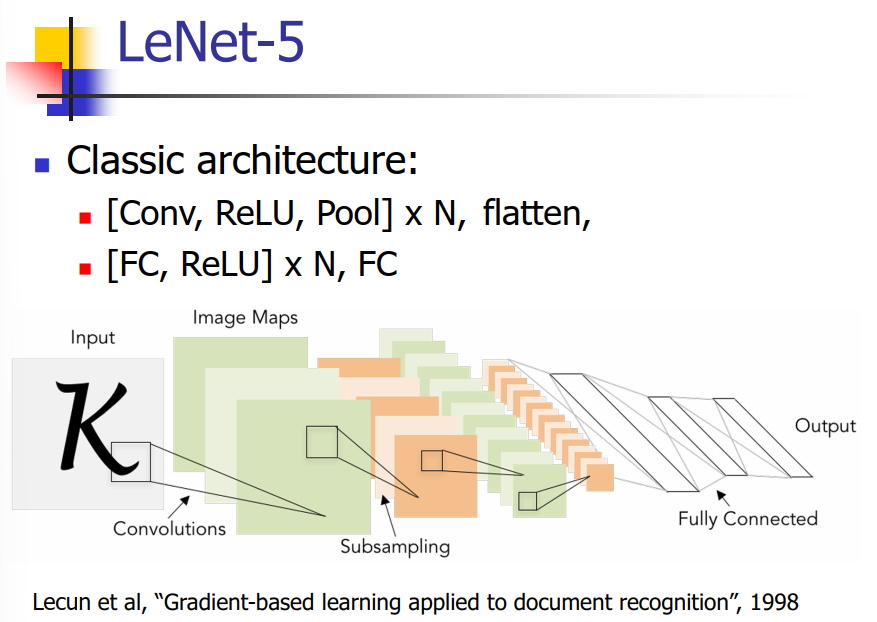

In [5]:
#Build Model - LeNet5
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
  import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
  def __init__(self):
      super(LeNet5, self).__init__()

      self.conv1 = nn.Conv2d(3, 6, kernel_size=5)   #leNet5 goc chi chay voi anh xam, nen can chuyen ve 3 channels
      self.pool = nn.AvgPool2d(2, 2)
      self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

      self.fc1 = nn.Linear(16 * 5 * 5, 120)  # CIFAR-10 shape
      self.fc2 = nn.Linear(120, 84)
      self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
      x = self.pool(F.relu(self.conv1(x)))  # (32→28→14)
      x = self.pool(F.relu(self.conv2(x)))  # (14→10→5)

      x = x.view(x.size(0), -1) #khong thay doi du lieu, chi doi cach nhin du lieu (khong tao copy nhu reshape())

      x = F.relu(self.fc1(x))
      x = F.relu(self.fc2(x))
      x = self.fc3(x)

      return x

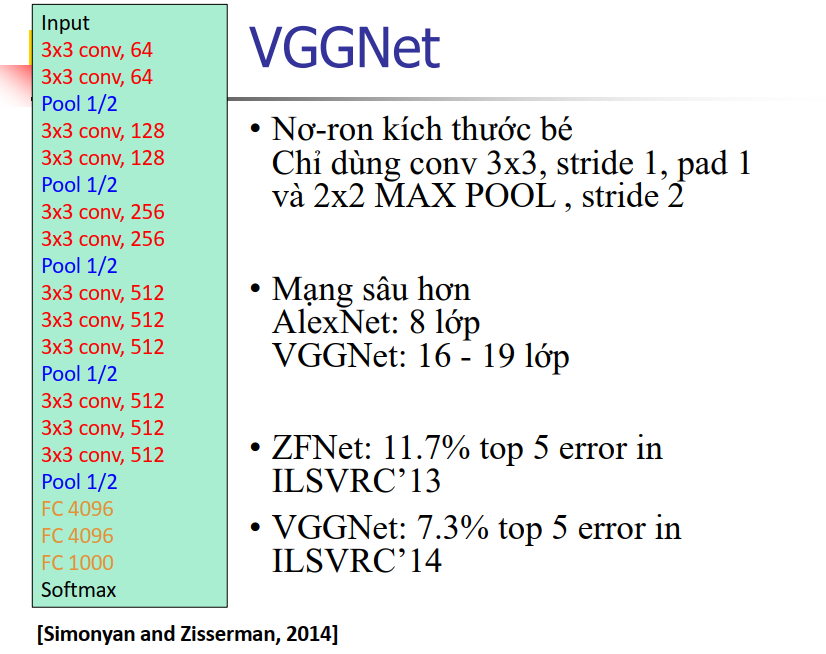

In [8]:
class VGGNet16(nn.Module):
  def __init__(self, num_classes=10):
    super(VGGNet16, self).__init__()

    self.features = nn.Sequential(
      # Block 1
      nn.Conv2d(3, 64, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(64, 64, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(2, 2),  # 32 → 16

      # Block 2
      nn.Conv2d(64, 128, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(128, 128, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(2, 2),  # 16 → 8

      # Block 3
      nn.Conv2d(128, 256, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(256, 256, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(256, 256, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(2, 2),  # 8 → 4

      # Block 4
      nn.Conv2d(256, 512, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(512, 512, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(512, 512, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(2, 2),  # 4 → 2

      # Block 5
      nn.Conv2d(512, 512, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(512, 512, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.Conv2d(512, 512, kernel_size=3, padding=1),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(2, 2)   # 2 → 1
    )

    self.classifier = nn.Sequential(
        nn.Linear(512*1*1, 512),
        nn.ReLU(True),
        nn.Dropout(),

        nn.Linear(512, 256),
        nn.ReLU(True),
        nn.Dropout(),

        nn.Linear(256, num_classes),
    )

  def forward(self, X):
    x = self.features(x)
    x = x.view(x.size(0), -1) # flatten
    x = self.classifier(x)
    return x


In [6]:
from torch.optim import optimizer
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LeNet5().to(device)

loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
  model.train()
  total_loss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = loss_func(outputs, labels)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.7318
Epoch 2, Loss: 1.4321
Epoch 3, Loss: 1.3189
Epoch 4, Loss: 1.2444
Epoch 5, Loss: 1.1834
Epoch 6, Loss: 1.1282
Epoch 7, Loss: 1.0803
Epoch 8, Loss: 1.0437
Epoch 9, Loss: 1.0088
Epoch 10, Loss: 0.9715


In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Acc: {100 * correct / total:.2f}%")

Acc: 62.50%
